**MODELE DE PRICING AUTO**
---

Choix sur la méthode :
- la jointure nécessite de supprimer les individus sans sinistres et donne une vision incomplète de la fréquence de sinistre. Nous ferons donc la jointure après avoir ajusté le modèle fréquence (la base sévérité n'apportant que le coût de sinistre comme information additionnelle).
- La sélection des variables a été faite par la méthode stepwise sur le critère de l'AIC (AIC=−2ℓ+2k, compromis précision du modèle / complexité.).
- Nous utilisons la validation croisée pour contrôler l'overfitting au lieu de splitter les datasets.
- Nous ajustons les GLMs avec statsmodels au lieu de scikit-learn pour avoir un plus grand choix de modèles (binomiale négative...) et parce que l'encodage est fait automatiquement avec patsy. 


In [37]:
#%% Import des librairies
import sklearn  
import seaborn as sns
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
import patsy


In [38]:
data_path1 = "../datasets/freMTPL2freq.csv"

data_path2 = "../datasets/freMTPL2sev.csv"

df_freq = pd.read_csv(data_path1)
df_sev = pd.read_csv(data_path2, sep=";")

On commence par la fréquence. On explore la base de données:
- Visualisation premières lignes et résumé
- Vérification données manquantes
- Vérification doublons


In [39]:
#Visualisation premières lignes et résumé sur la fréquence
print(df_freq.head())
print(df_freq.info()) 
df_freq  

   IDpol  ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus VehBrand  \
0    1.0        1      0.10         5       0       55          50      B12   
1    3.0        1      0.77         5       0       55          50      B12   
2    5.0        1      0.75         6       2       52          50      B12   
3   10.0        1      0.09         7       0       46          50      B12   
4   11.0        1      0.84         7       0       46          50      B12   

    VehGas Area  Density       Region  
0  Regular    D     1217  Rhone-Alpes  
1  Regular    D     1217  Rhone-Alpes  
2   Diesel    B       54     Picardie  
3   Diesel    B       76    Aquitaine  
4   Diesel    B       76    Aquitaine  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   E

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine
...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne


IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64


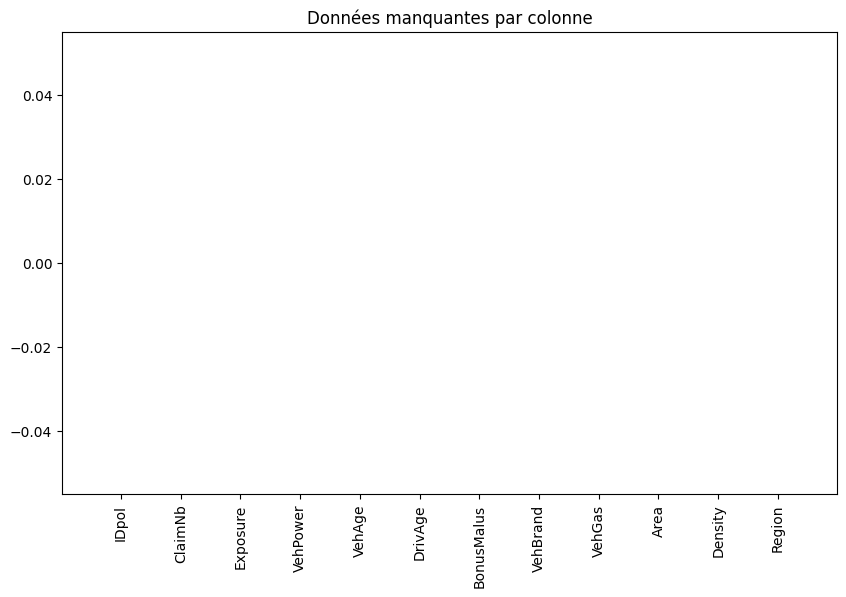

In [40]:
#on teste les données manquantes
print(df_freq.isnull().sum())  
#On fait un plot des données manquantes
plt.figure(figsize=(10,6))
plt.bar(df_freq.columns, df_freq.isnull().sum())
plt.xticks(rotation=90)
plt.title("Données manquantes par colonne")
plt.show() 

In [41]:
#On teste les doublons, En sachant que IDPol est un identifiant de police s'il est unique il ne doit pas y avoir de doublon
print("Nombre de doublons dans la base de fréquence:", df_freq.duplicated().sum())

Nombre de doublons dans la base de fréquence: 0


ANALYSE UNIVARIEE

In [42]:
print(df_freq.describe())   # Résumé statistique des colonnes numériques

              IDpol        ClaimNb       Exposure       VehPower  \
count  6.780130e+05  678013.000000  678013.000000  678013.000000   
mean   2.621857e+06       0.053247       0.528750       6.454631   
std    1.641783e+06       0.240117       0.364442       2.050906   
min    1.000000e+00       0.000000       0.002732       4.000000   
25%    1.157951e+06       0.000000       0.180000       5.000000   
50%    2.272152e+06       0.000000       0.490000       6.000000   
75%    4.046274e+06       0.000000       0.990000       7.000000   
max    6.114330e+06      16.000000       2.010000      15.000000   

              VehAge        DrivAge     BonusMalus        Density  
count  678013.000000  678013.000000  678013.000000  678013.000000  
mean        7.044265      45.499122      59.761502    1792.422405  
std         5.666232      14.137444      15.636658    3958.646564  
min         0.000000      18.000000      50.000000       1.000000  
25%         2.000000      34.000000      50.000

sur Region et Vehicule brand il y a des modalités peu représentées.

## Analyse bivariée

L’objectif de cette étape est d’étudier la relation entre la variable cible **ClaimNb** (nombre de sinistres) et les autres variables explicatives, qu’elles soient **numériques** ou **catégorielles**.  
Cela permet d’identifier les variables susceptibles d’avoir un effet significatif sur la fréquence des sinistres, avant la modélisation GLM.

---

### Variables numériques
Pour les variables quantitatives (ex. *VehAge*, *DrivAge*, *BonusMalus*, *Density*...), l’objectif est de détecter d’éventuelles relations linéaires ou monotones avec la variable cible.

- **Scatterplots** de chaque variable numérique en fonction de *ClaimNb* afin de visualiser les tendances globales.  
- **Coefficients de corrélation** :
  - **Pearson** : mesure de la relation linéaire.  
  - **Spearman** : mesure de la relation monotone (non nécessairement linéaire).  


> Ces analyses permettent d’identifier les variables numériques les plus corrélées à la fréquence des sinistres, mais elles ne préjugent pas d’une relation causale.



### Variables catégorielles
Pour les variables qualitatives (ex. *VehBrand*, *VehGas*, *Area*, *Region*...), l’objectif est d’évaluer si les moyennes de *ClaimNb* diffèrent selon les modalités.

- **Barplots** de la fréquence moyenne de sinistres (`ClaimNb` moyen) par modalité.  
 
- **Corrélation de ratio (η)** pour mesurer la part de variance de *ClaimNb* expliquée par chaque variable catégorielle.  


> Le V de Cramer n’a pas été retenu ici, car il ne s’applique qu’à deux variables qualitatives.  
> La corrélation de ratio η est plus adaptée pour un lien entre une variable quantitative (ClaimNb) et une variable qualitative.


**Remarque :**  
Cette analyse bivariée ne suffit pas à elle seule pour la sélection finale des variables du modèle, mais elle constitue une première étape essentielle pour identifier les variables les plus pertinentes et éviter d’inclure des prédicteurs sans pouvoir explicatif.


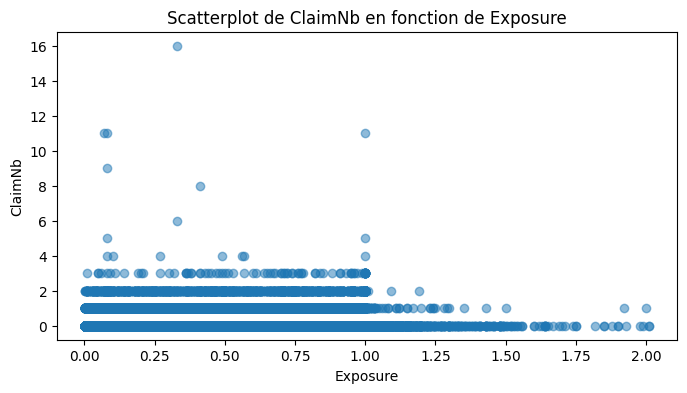

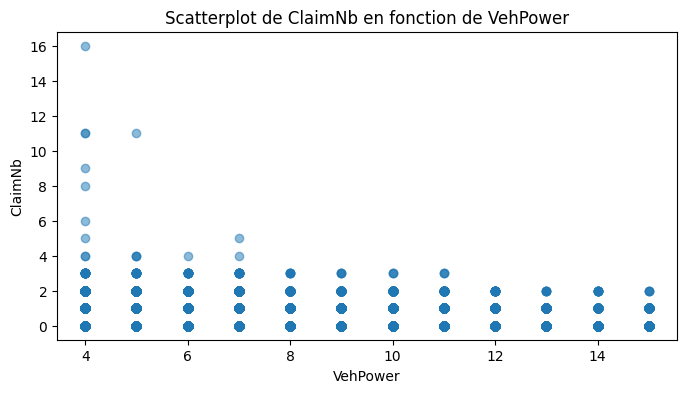

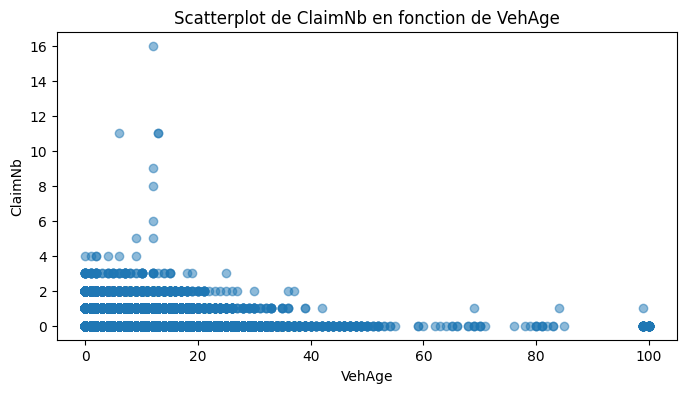

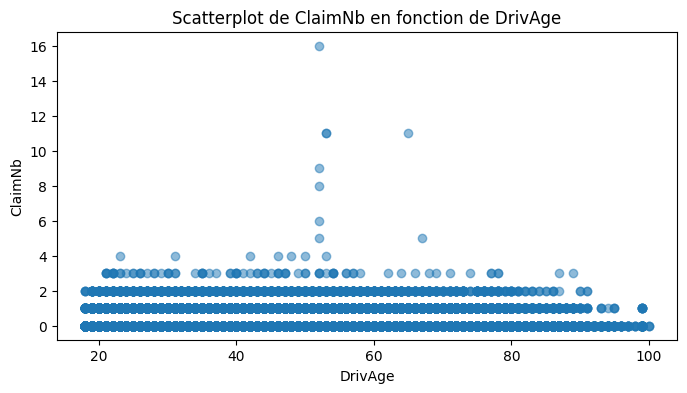

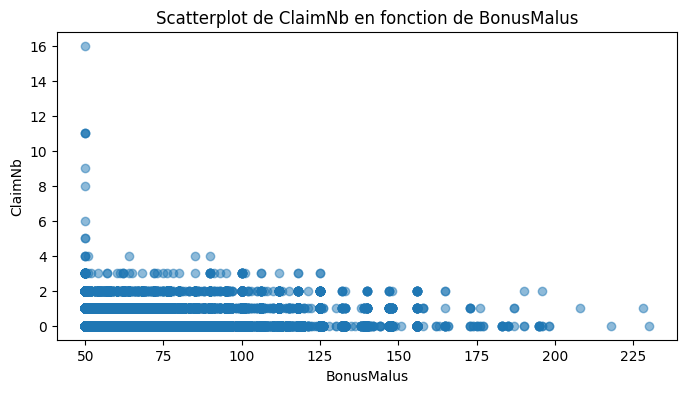

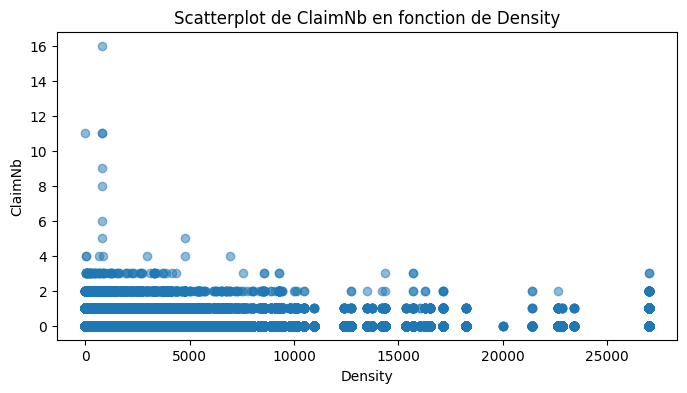

In [43]:
# faire des Scatterplots de chaque variable numérique en fonction de ClaimNb en excluant IDpol
num_cols = df_freq.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if col != 'ClaimNb' and col != 'IDpol':
        plt.figure(figsize=(8, 4))
        plt.scatter(df_freq[col], df_freq['ClaimNb'], alpha=0.5)
        plt.title(f'Scatterplot de ClaimNb en fonction de {col}')
        plt.xlabel(col)
        plt.ylabel('ClaimNb')
        plt.show()      



Il n'y a pas de relation linéaire entre les variables.
 
 Il y a une *forte représentation des zéros et des individus s'écartant de la norme :* Résultat normal et cohérent sur une étude de sinistralité.

 Le coefficient de Pearson semble être une mesure non adaptée. Nous calculerons les coefficients de Spearman (qui mesurent la relation non linéaire mais monotones). 

In [44]:
#Calcul des coéfficients de corrélation de Spearman entre les variables numériques, sur un échantillon aléatoire de 10000 lignes pour des raisons de performance
sample_df = df_freq.sample(n=10000, random_state=42)
corr_matrix = sample_df[num_cols].corr(method='spearman')

#Afficher juste la corrélation entre ClaimNb et les autres variables
print("Corrélation de Spearman entre ClaimNb et les autres variables:")
print(corr_matrix['ClaimNb'].sort_values(ascending=False))


Corrélation de Spearman entre ClaimNb et les autres variables:
ClaimNb       1.000000
Exposure      0.066293
BonusMalus    0.048613
Density       0.019513
DrivAge       0.000791
VehPower     -0.009965
VehAge       -0.035789
IDpol        -0.125329
Name: ClaimNb, dtype: float64


Des coefficients faibles indiquent l’absence de relation linéaire ou monotone marquée, ce qui justifie l’utilisation d’un modèle non linéaire et non gaussien (GLM).

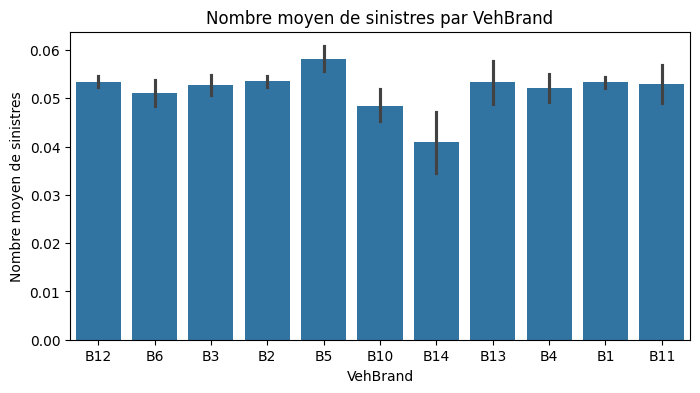

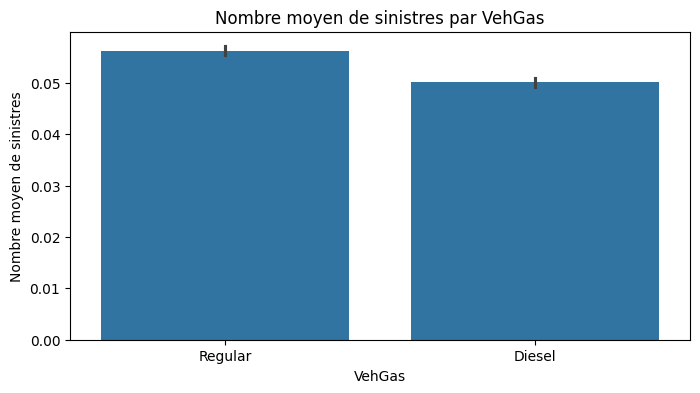

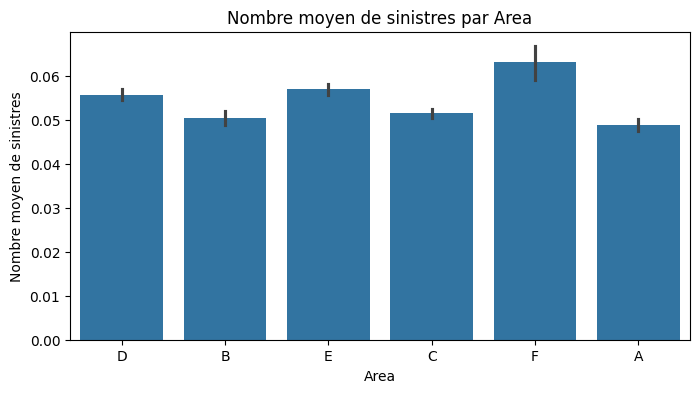

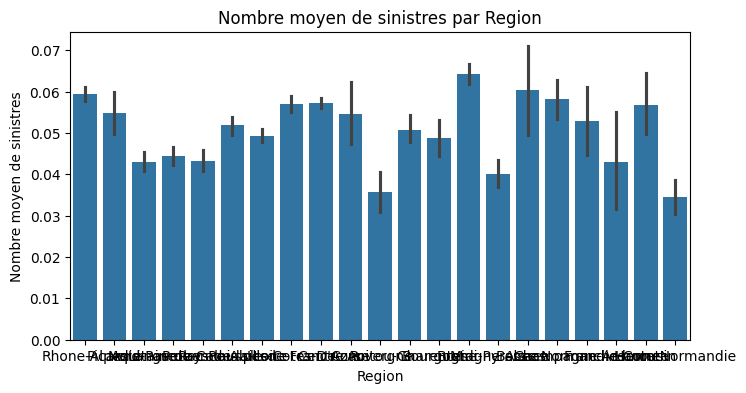

In [45]:
#Pour les variables catégorielles **Barplots** de nombre moyen de sinistres (`ClaimNb` moyen) par modalité
cat_cols = df_freq.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=col, y='ClaimNb', data=df_freq, estimator=np.mean)
    plt.title(f'Nombre moyen de sinistres par {col}')
    plt.xlabel(col)
    plt.ylabel('Nombre moyen de sinistres')
    plt.show()


Les variables catégorielles semblent correlées au nombre moyen de sinistres, particulièrement la région.

In [46]:
# Calculer eta (sqrt(SSB/SST)) pour chaque variable catégorielle sur un échantillon aléatoire de 10000 lignes       


def eta_caree(df, target, cat_cols):
    """
    Retourne la série des eta (sqrt(SSB/SST)) pour chaque colonne catégorielle.
    df : DataFrame, target : nom de la cible (str), cat_cols : list de colonnes catégorielles.
    """
    y = df[target]
    # SST total
    y_mean = y.mean()
    SST = ((y - y_mean)**2).sum()
    res = {}
    for col in cat_cols:
        grp = df[[col, target]].dropna().groupby(col)[target]
        if grp.ngroups < 2 or SST == 0:
            res[col] = np.nan
            continue
        sizes = grp.size()
        means = grp.mean()
        SSB = ((means - y_mean)**2 * sizes).sum()
        eta2 = SSB / SST
        res[col] = np.sqrt(eta2)  # retourne η (entre 0 et 1)
    return pd.Series(res).sort_values(ascending=False)

# Usage
cat_cols = df_freq.select_dtypes(include=['object', 'category']).columns.tolist()
eta = eta_caree(sample_df, 'ClaimNb', cat_cols)
print(eta)

Region      0.045883
VehBrand    0.044618
Area        0.023341
VehGas      0.013558
dtype: float64



Les coefficients d’êta-carré, montrent des effets faibles à modérés pour certaines variables catégorielles :  
- **Region** et **VehBrand** présentent les η² les plus élevés sur le nombre de sinistres.  
- **Area** et **VehGas** ont un effet plus faible mais cohérent (densité urbaine, profil conducteur).

Ces résultats confirment que la sinistralité dépend de multiples facteurs reliés entre eux de manière non linéaire,  
ce qui justifie l’utilisation d’un **modèle linéaire généralisé (GLM)** .
